### Exploring Ultra-Flexible Tentacle Electrode Data - MOUSE Dorsal CA1 + Dentate Gyrus

This notebook serves to explore different preprocessing and postprocessing steps with spikeInterface using UFTE LFP data. 

***
### Loading data

In [1]:
import spikeinterface as si 
import spikeinterface.preprocessing as spre
from dataLoading_utils import getXMLData
from dataAnalysis_utils import find_repetitive_channels
import numpy as np
import spikeinterface.widgets as sw
import matplotlib.pyplot as plt
from probeinterface import Probe, ProbeGroup, generate_linear_probe, generate_multi_shank, combine_probes 
from probeinterface.plotting import plot_probe

In [2]:
dat_path = r"D:\Yanik Lab Dropbox\Peter Gombkoto\Multiarea rat recordings\External_Data\Viktor_Budapest\3170_day8_260415_170145\amplifier.dat" 
xml_path = r"D:\Yanik Lab Dropbox\Peter Gombkoto\Multiarea rat recordings\External_Data\Viktor_Budapest\3170_day8_260415_170145\amplifier.xml" 

channel_ids, skippedChannels, xml_data = getXMLData(xml_path)
nBits, nChannels, samplingRate, offset, lfpSamplingRate = xml_data

samplingRate = 20000 # for viktor mouse XML is wrong

print(f"Number of bits: {nBits}, Number of channels: {nChannels}, Sampling rate: {samplingRate} Hz, Offset: {offset}, LFP sampling rate: {lfpSamplingRate} Hz")

uV_per_count = 0.195 #https://intantech.com/files/Intan_RHX_user_guide.pdf

# TODO: Voltage range ? = 10

Number of bits: 16, Number of channels: 64, Sampling rate: 20000 Hz, Offset: 0.0, LFP sampling rate: 2000.0 Hz


### Create a Recording object

Select only channels from shank 2 ([31:])

In [3]:
full_recording = si.read_binary(file_paths=dat_path, sampling_frequency=samplingRate, dtype=f"int{nBits}", num_channels=nChannels, channel_ids=np.arange(nChannels), is_filtered=False, gain_to_uV=uV_per_count, offset_to_uV=0.0)

shank2_channel_ids = np.array(channel_ids[32:])
shank2_recording = full_recording.select_channels(channel_ids=shank2_channel_ids)

shank2_recording

ChannelSliceRecording: 32 channels - 20.0kHz - 1 segments - 75,886,464 samples 
                       3,794.32s (1.05 hours) - int16 dtype - 4.52 GiB

In [4]:
%matplotlib widget

traces = shank2_recording.get_traces(channel_ids=shank2_channel_ids[-10:], start_frame=0, end_frame=10000, return_in_uV=True)  
sw.plot_traces(shank2_recording, channel_ids=shank2_channel_ids[-10:], return_in_uV=True, backend="ipywidgets")


AppLayout(children=(TimeSlider(children=(Dropdown(description='Segment', options=(0,), value=0), Button(icon='…

### Create a Probe

First create a flat probe given the known geometry and model the wire bending to get the final x and y coordinates for each contact site. 

We will first work with shank 3. The flat probe has 50um between each contact site in depth 

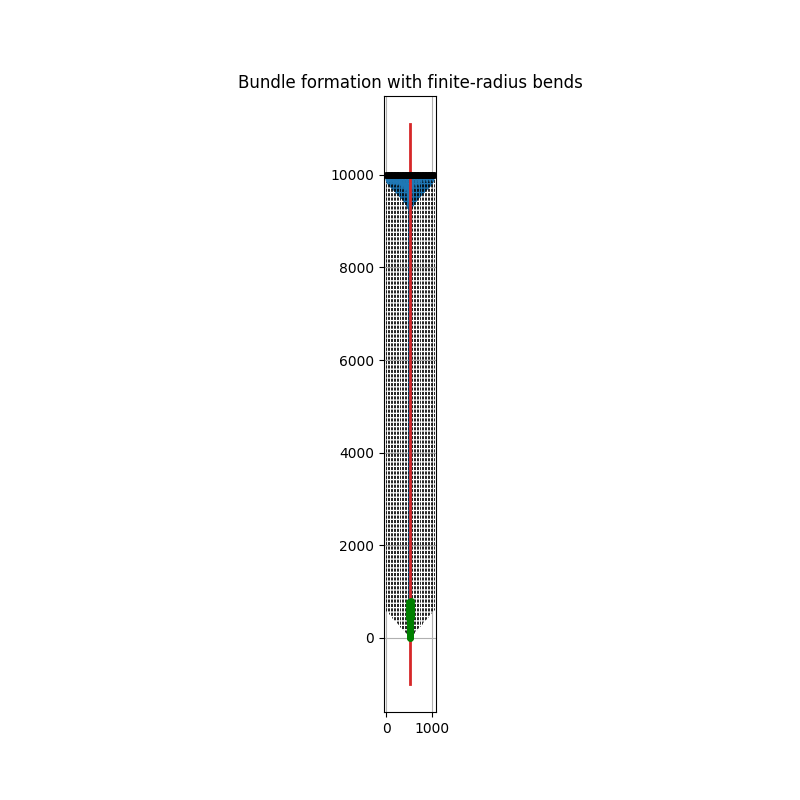

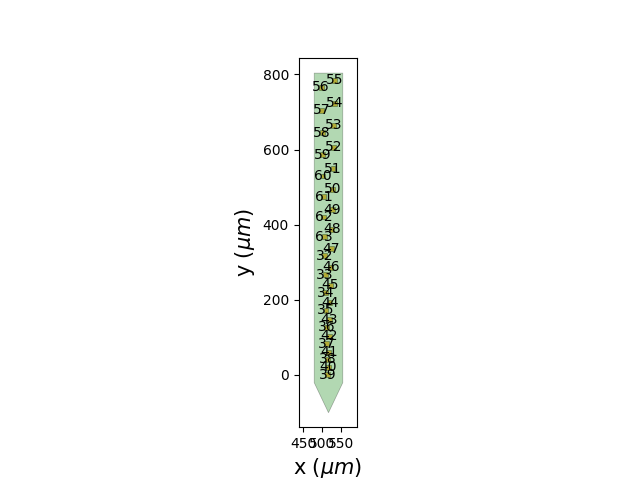

In [5]:
from probeGeom import create_flat_geom
from clean_bending_model import BundleParameters, run_from_array

# set parameters for probe geometry 
num_contact_sites = 32
y_flat_contact_dist = 19.5 # um 
x_flat_contact_dist = 33.3 # um (based on figure from https://www.nature.com/articles/s41467-024-49226-9#Sec7)
base_length = 10000.0  # choose something comfortably larger than the max y offset

# create the flat geometry for the electrode tips and the base of the probe
electrode_tips = create_flat_geom(num_contact_sites, x_flat_contact_dist, y_flat_contact_dist)
electrode_base = np.column_stack((electrode_tips[:,0], np.ones(num_contact_sites)*base_length))

# model the bundling of the probe and get the new coordinates for the electrode tips and ends of the probe
#TODO: find better params ? 
params = BundleParameters(
    first_bend_distance=150.0,
    max_bend_angle_deg=45.0,
    bundle_ratio=0.035,
    first_radius=300.0,
    second_radius=300.0,
)

result = run_from_array(electrode_base, electrode_tips,params=params, make_plot=True) # positions are in result.ends and result.tips

# create the SpikeInterface probe object and plot it
probe = Probe(ndim=2, si_units='um')
probe.set_contacts(positions=result.ends, shapes=np.array(['square'] * num_contact_sites), shape_params={"width": 13})
# set the contact IDs for each site 
probe.set_device_channel_indices(np.arange(num_contact_sites))
probe.set_contact_ids(shank2_channel_ids)
probe.create_auto_shape()

# plot the probe geometry to check it looks correct
# plot_probe(probe, with_contact_id=True, with_device_index=True)
    
# link the probe geometry to our recording object 
shank2_recording.set_probe(probe, in_place=True)

sw.plot_probe_map(shank2_recording, with_channel_ids=True, backend="matplotlib")

# Preprocessing: 
### Remove Noisy Channels

First those labeled in the XML file and next those detected by SpikeInterface 

Shank 2 channels to skip: [36 62]


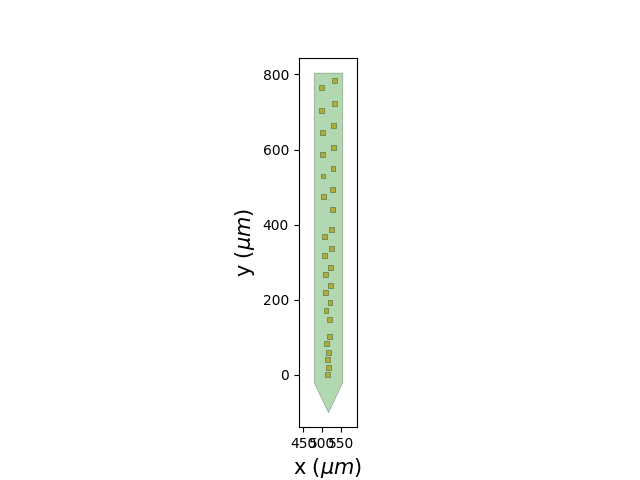

In [6]:
# STEP 1: remove channels already identified as bad in the xml file
shank2_skipped_channels = np.intersect1d(shank2_channel_ids, skippedChannels)
print(f"Shank 2 channels to skip: {shank2_skipped_channels}")  


clean_recording = shank2_recording.remove_channels(shank2_skipped_channels)
clean_channel_ids = clean_recording.get_channel_ids()
sw.plot_probe_map(clean_recording, backend="matplotlib")

IBL-defined Bad channel IDs: []


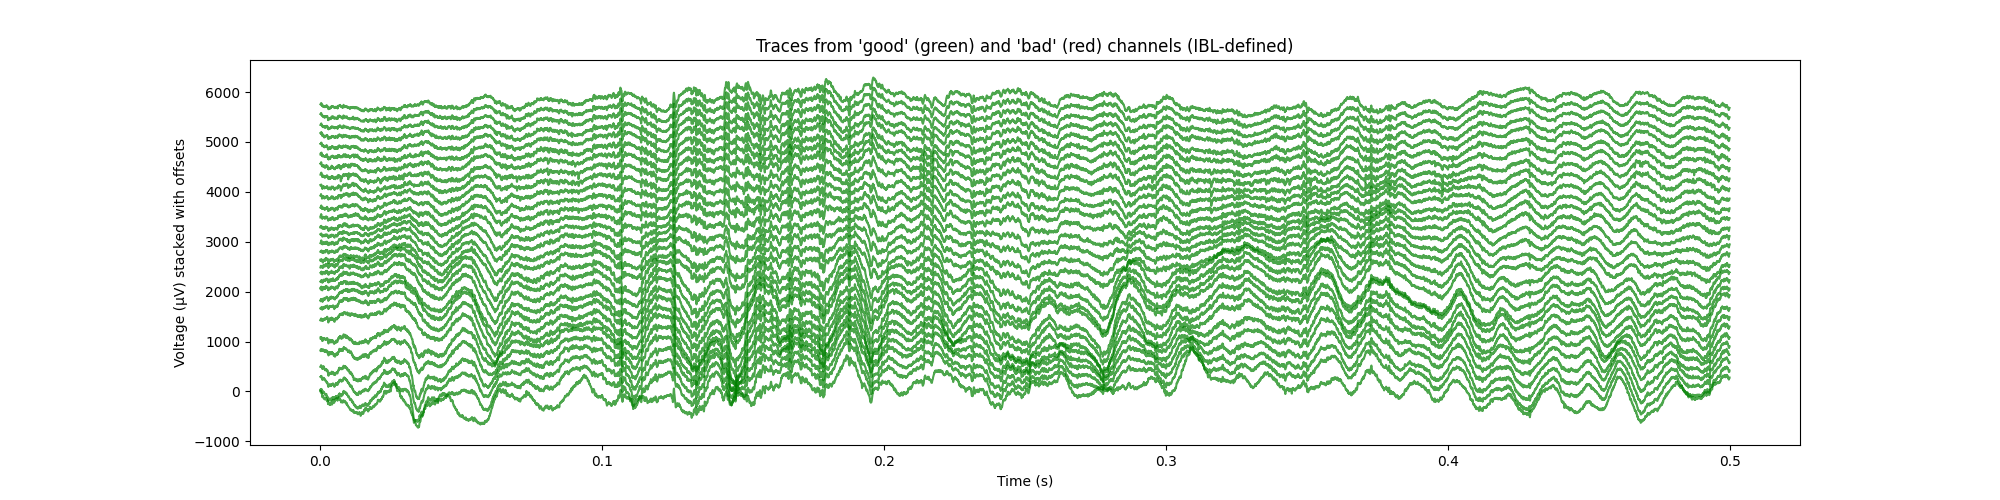

In [7]:
# STEP 2: detect bad channels as defined by IBL 

bad_channel_ids, channel_labels = spre.detect_bad_channels(clean_recording, 
                         method='coherence+psd', 
                         std_mad_threshold=5, 
                         psd_hf_threshold=0.02,
                         dead_channel_threshold=-0.5, 
                         noisy_channel_threshold= 1.0, 
                         outside_channel_threshold=-0.75, 
                         outside_channels_location= 'top', # Literal['top', 'bottom', 'both']
                         n_neighbors = 11, 
                         nyquist_threshold =  0.8, 
                         direction = 'y', # Literal['x', 'y', 'z'] 
                         chunk_duration_s = 0.3, 
                         num_random_chunks = 100, 
                         welch_window_ms = 10.0, 
                         highpass_filter_cutoff = 300, 
                         neighborhood_r2_threshold = 0.9,
                         neighborhood_r2_radius_um = 30.0, 
                         seed = None, 
                         channel_filters = None)

print(f"IBL-defined Bad channel IDs: {bad_channel_ids}")

# plot trace examples with 'good' and 'bad' channels to see if they look different
traces = clean_recording.get_traces(channel_ids=clean_channel_ids, start_frame=0, end_frame=10000, return_in_uV=True)
offsets = np.arange(traces.shape[1]) * 200
offsets = offsets[::-1]
t = np.arange(traces.shape[0]) / (samplingRate) # Time vector in seconds
plt.figure(figsize=(20, 5))
for i, id in enumerate(clean_channel_ids):
    color = 'red' if id in bad_channel_ids else 'green'
    plt.plot(t, traces[:, i] + offsets[i], alpha=0.7, color=color)

plt.xlabel("Time (s)")
plt.ylabel("Voltage (µV) stacked with offsets")
plt.title("Traces from 'good' (green) and 'bad' (red) channels (IBL-defined)")
plt.show()

### Detecting artifact periods

In [ ]:
art_periods = spre.detect_artifact_periods(clean_recording, 'envelope')
# method: Literal['envelope', 'saturation'] 

print("done")

In [ ]:
l = []
artifact_mask = np.zeros(len(traces), dtype=bool)
for data in art_periods:
    start = data[1]
    stop = data[2]
    if stop < len(traces):
        artifact_mask[start:stop] = True
        length = ((stop - start) / 30000) * 1000 # l in ms 
        l.append(length)
        

print(f"{len(l)} artifacts with mean duration of {np.mean(l).round(3)}ms")
    
change_idx = np.where(np.diff(artifact_mask.astype(int)) != 0)[0] + 1
segs = np.split(np.arange(len(traces)), change_idx)

plt.figure() 
for seg in segs:
    color = 'red' if artifact_mask[seg[0]] else 'green'
    plt.plot(traces[seg], color=color)

plt.show()

***

### Preprocessing

Beware of which steps do and do not use the probe geometry. 

Geometry agnostic: bandpass_filter, highpass_filter, notch_filter, generic filter, center, zscore, scale, clip, astype, resample, rectify, phase_shift, whiten

Geometry-dependent: CAR, average_across_direction, directional_derivative, highpass_spatial_filter, depth_order, compute_motion, correction_motion

Kilosort4 performs the following preprocessing steps:
1. remove mean across channels 
2. CAR
3. temporal filtering per-channel filtering high pass filter at 300Hz 
4. local channel whitening (uses local 32 channels) 
5. drift estimation and correction 

In [ ]:
KS_P1 = si.preprocessing.center(clean_recording, mode='mean', dtype='float32')

KS_P2 = si.preprocessing.highpass_filter(KS_P1, freq_min=300.0)

# JR clust uses median, KS4 uses average
KS_P3 = si.preprocessing.common_reference(recording = KS_P2, reference = 'global', operator='median')    # median may be better as its not sensitive to big spikes or bad channels / more robust 


KS_P3a = si.preprocessing.highpass_spatial_filter(recording=KS_P2, n_channel_pad=None)

#KS_P4 = si.preprocessing.whiten(recording = KS_P3, mode='global') # VERY BAD ! WHY?


noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

In [61]:
sw.plot_traces(KS_P3, backend='ipywidgets')

AppLayout(children=(TimeSlider(children=(Dropdown(description='Segment', options=(0,), value=0), Button(icon='…

In [ ]:
from spikeinterface.sorters import run_sorter, get_default_sorter_params, get_sorter_params_description
from spikeinterface.sortingcomponents.peak_detection import detect_peaks

peaks3_5 = detect_peaks(recording=KS_P3, method='locally_exclusive', peak_sign='neg', detect_threshold=5, exclude_sweep_ms=0.2) #, noise_levels=None)
peaks3_3 = detect_peaks(recording=KS_P3, method='by_channel', peak_sign='neg', detect_threshold=3, exclude_sweep_ms=0.2) #, noise_levels=None)


#peaks3 = detect_peaks(recording=KS_P3, method='locally_exclusive', peak_sign='neg', detect_threshold=5, exclude_sweep_ms=0.2)
#peaks3a = detect_peaks(recording=KS_P3a, method='locally_exclusive', peak_sign='neg', detect_threshold=5, exclude_sweep_ms=0.2)

c:\Users\social\Desktop\temp_Brune\spikeinterface\venv_SI\Lib\site-packages\spikeinterface\sortingcomponents\peak_detection\main.py:60: UserWarning: The signature of detect_peaks() has changed, now method_kwargs and job_kwargs are dinstinct params.This warning will raise an error in version 0.105.0
  warnings.warn(


noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

detect peaks (locally_exclusive) (no parallelization):   0%|          | 0/3795 [00:00<?, ?it/s]

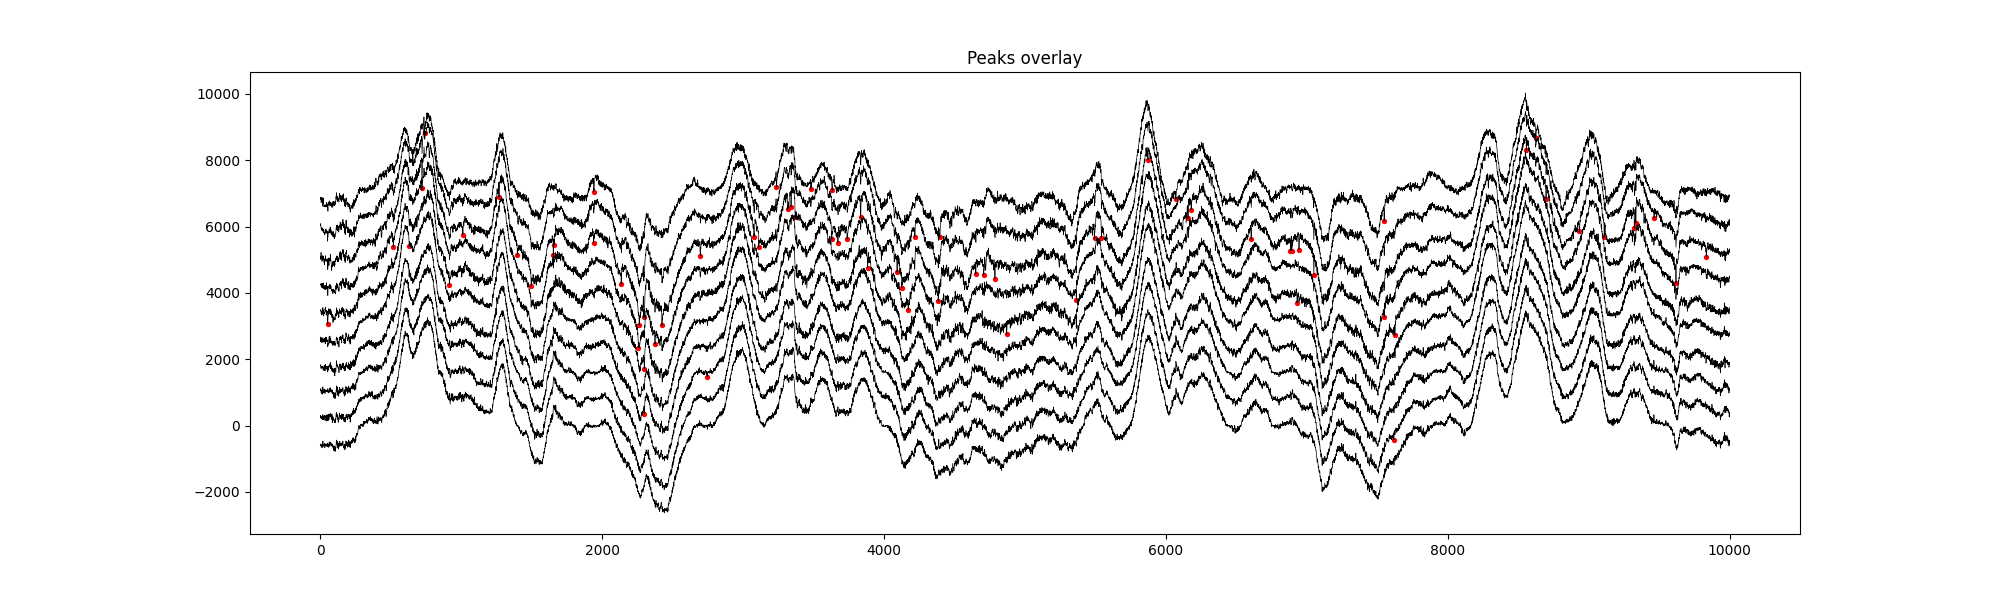

In [50]:
fs = 20000
p = peaks3
k2 = False
trace_data = si.preprocessing.common_reference(recording = KS_P1, reference = 'global', operator='median')    # median may be better as its not sensitive to big spikes or bad channels / more robust 


start_s = 10
duration_s = 0.5

start = int(start_s * fs)
end = int((start_s + duration_s) * fs)

traces = trace_data.get_traces(start_frame=start, end_frame=end)

# shift peaks into window
mask = (p["sample_index"] >= start) & (p["sample_index"] < end)
peaks_win = p[mask]
if k2:
    color = 'red' 
else:
    color = 'green' 


num_ch = 10
offset = 800 # vertical spacing

plt.figure(figsize=(20, 6))

for ch in range(num_ch):
    
    plt.plot(traces[:, ch] + ch * offset, color='black', linewidth=0.5)

    p = peaks_win[peaks_win["channel_index"] == ch]
    times = p["sample_index"] - start

    plt.scatter(times, traces[times, ch] + ch * offset, color='red', s=8)

plt.title("Peaks overlay")
plt.show()




In [ ]:
def match_peaks_tol(peaks1, peaks2, tol=2):
    t1, c1 = peaks1["sample_index"], peaks1["channel_index"]
    t2, c2 = peaks2["sample_index"], peaks2["channel_index"]

    order2 = np.lexsort((t2, c2))
    t2s, c2s = t2[order2], c2[order2]

    matched1 = np.zeros(len(peaks1), dtype=bool)

    for ch in np.unique(c1):
        idx1 = np.where(c1 == ch)[0]

        left = np.searchsorted(c2s, ch, side="left")
        right = np.searchsorted(c2s, ch, side="right")
        if left == right:
            continue

        t2_ch = t2s[left:right]
        t1_ch = t1[idx1]

        pos = np.searchsorted(t2_ch, t1_ch)

        match = np.zeros(len(t1_ch), dtype=bool)

        valid = pos < len(t2_ch)
        match[valid] |= np.abs(t2_ch[pos[valid]] - t1_ch[valid]) <= tol

        valid = pos > 0
        match[valid] |= np.abs(t2_ch[pos[valid]-1] - t1_ch[valid]) <= tol

        matched1[idx1] = match

    return matched1



m3 = match_peaks_tol(peaks3, peaks4, tol=5)
m4 = match_peaks_tol(peaks4, peaks3, tol=5)
m3a = match_peaks_tol(peaks3a, peaks3, tol=5)

common = peaks3[m3]
u3 = peaks3[~m3]
u4 = peaks4[~m4]

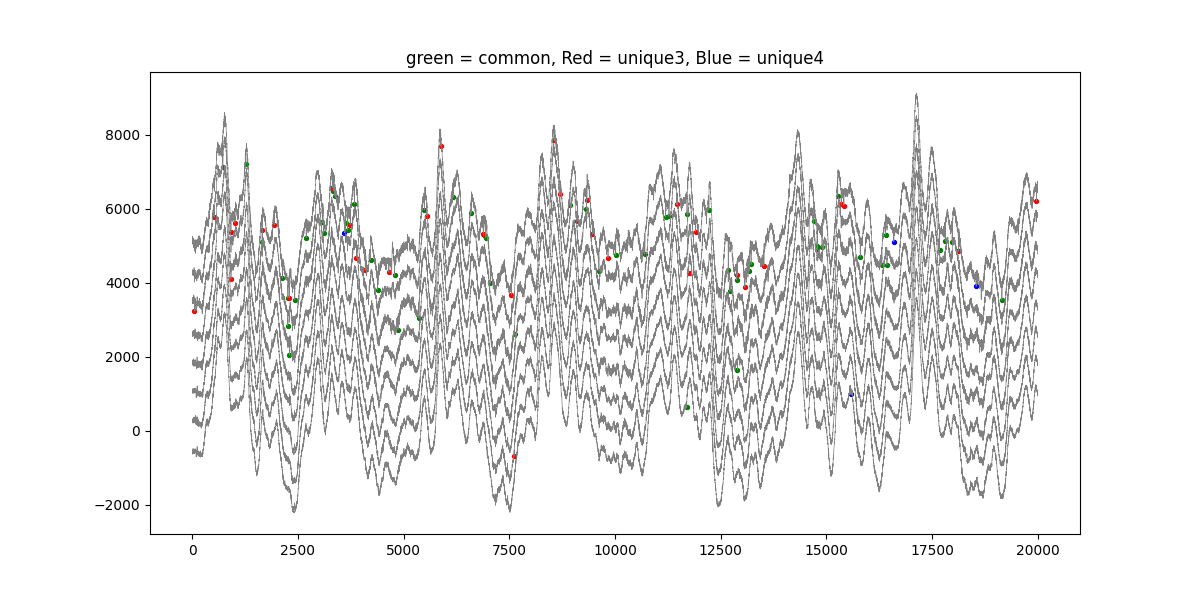

In [18]:
fs = KS_P2.get_sampling_frequency()

start_s = 10
duration_s = 1

start = int(start_s * fs)
end = int((start_s + duration_s) * fs)

traces = KS_P2.get_traces(start_frame=start, end_frame=end)

num_ch = 8
offset = 800

plt.figure(figsize=(12, 6))

for ch in range(num_ch):
    plt.plot(traces[:, ch] + ch*offset, color='gray', linewidth=0.5)

    def plot_group(peaks, color):
        mask = (
            (peaks["channel_index"] == ch) &
            (peaks["sample_index"] >= start) &
            (peaks["sample_index"] < end)
        )
        p = peaks[mask]
        t = p["sample_index"] - start
        plt.scatter(t, traces[t, ch] + ch*offset, color=color, s=8)

    plot_group(common, 'green')
    plot_group(u3, 'red')
    plot_group(u4, 'blue')

plt.title("green = common, Red = unique3, Blue = unique4")
plt.show()



In [ ]:
w_ts = sw.plot_traces(recording, channel_ids=channel_ids[:10])

In [ ]:
def rms_per_channel(rec, duration_s=30):
    fs = rec.get_sampling_frequency()
    traces = rec.get_traces(end_frame=int(fs*duration_s), return_scaled=True)
    return np.sqrt(np.mean(traces**2, axis=0))



# Spike sorting

In [ ]:
from spikeinterface.sorters import run_sorter, get_default_sorter_params, get_sorter_params_description

params = get_default_sorter_params('kilosort4')
print("Parameters:\n", params)

descriptions = get_sorter_params_description('kilosort4')
print("Descriptions:\n", descriptions)

print(descriptions['dmin'])


In [ ]:
KS4_params = {
 'batch_size': 60000,
 #'dminx': 10,
 'do_CAR': True,
 'do_correction': False, # False = don't do drift correction
 'max_threads_per_worker': 1,
 'max_channel_distance': 50,
 'n_jobs': 1,
 'nblocks': 0,
 'nearest_chans': 10,
 'nearest_templates': 100,
 'nt': 61,
 'pool_engine': 'process',
 'progress_bar': True,
 #'scale': uV_per_count, # set to make sure the traces are +- 100 as desired by kilosort  
 'skip_kilosort_preprocessing': True,
 'torch_device': 'cuda'}

sorting_KS4 = run_sorter(sorter_name='kilosort4', recording=clean_recording, folder='SI_SortingResults/KS4_April_28_2026_B', docker_image="ks4-blackwell-cu128", verbose=True,**KS4_params)
                         
                         

The following data is created as an output from the run_sorter function w/ Kilsort4:



***
***

Current questions: 
- distances between contact sites for our flexible electrodes are not constant
- probes are not inserted vertically so they have a z component as well, does this make a difference
- the xc are all identical as we assume contact sites to be about stacked on the vertical axis. is this a valid assumption 

***

***

**consider using the read_binary_folder function to concatinate multiple sessions together

*** 
## Analyzing Sorting Results

In [ ]:
from spikeinterface.extractors import read_kilosort_as_analyzer

job_kwargs = dict(n_jobs=-1, progress_bar=True, chunk_duration="1s")

sorting_analyzer = si.create_sorting_analyzer(sorting_KS4, clean_recording)

#output_path = 'SI_SortingResults/KS4_April_22_2026/sorter_output'
#sorting_analyzer = read_kilosort_as_analyzer(output_path, gain_to_uV=0.195, offset_to_uV=0.0)
#sorting_analyzer.set_temporary_recording(clean_recording)

sorting_analyzer.compute("random_spikes", method="uniform", max_spikes_per_unit=500)
sorting_analyzer.compute("waveforms", **job_kwargs)
sorting_analyzer.compute("templates", **job_kwargs)
sorting_analyzer.compute("noise_levels")
sorting_analyzer.compute("unit_locations", method="monopolar_triangulation")
sorting_analyzer.compute("isi_histograms")
sorting_analyzer.compute("correlograms", window_ms=100, bin_ms=5.)
sorting_analyzer.compute("principal_components", n_components=3, mode='by_channel_global', whiten=True, **job_kwargs)
sorting_analyzer.compute("quality_metrics", metric_names=["snr", "firing_rate"])
sorting_analyzer.compute("template_similarity")
sorting_analyzer.compute("spike_amplitudes", **job_kwargs)

# ----------------------------------------------------------------------------------------------------------------------------



Open the SpikeInterface GUI to analyze data

In [ ]:
# load either with python or with spikeinterface 

sw.plot_sorting_summary(sorting_analyzer, backend="spikeinterface_gui")

In [ ]:
sw.plot_unit_locations(sorting_analyzer, figsize=(4, 8))


In [ ]:
unit_ids = sorting_analyzer.unit_ids[:4]
sw.plot_unit_waveforms_density_map(sorting_analyzer, unit_ids=unit_ids, figsize=(14, 8))

In [ ]:
unit_ids = sorting_analyzer.unit_ids
sw.plot_unit_probe_map(sorting_analyzer, unit_ids=[14], figsize=(20, 8))


plt.show()

In [ ]:
unit_ids = sorting_analyzer.unit_ids
sw.plot_unit_waveforms(sorting_analyzer, unit_ids=[14], figsize=(16, 4))


In [ ]:
ext_templates = sorting_analyzer.get_extension("templates")

av_templates = ext_templates.get_data(operator="average")

for unit_index, unit_id in enumerate(sorting_analyzer.unit_ids[10:20]):
    fig, ax = plt.subplots()
    template = av_templates[unit_index]
    ax.plot(template)
    ax.set_title(f"{unit_id}")

***

## Comparing Kilosort 4 and JRClust

SpikeInterface accepts the following output data formats 
- `JRCSortingExtractor`
- `KiloSortSortingExtractor`

Available keys: ['#refs#', '#subsystem#', 'annotatedOnly', 'centerSites', 'clusterCenters', 'clusterCentroids', 'clusterNotes', 'clusterSites', 'curatedOn', 'detectTime', 'detectedOn', 'editPos', 'featuresShape', 'filtShape', 'history', 'initialClustering', 'meanSiteThresh', 'meanWfGlobal', 'meanWfGlobalRaw', 'meanWfLocal', 'meanWfLocalRaw', 'meanWfRawHigh', 'meanWfRawLow', 'nSitesOverThresh', 'nSpikes', 'ordRho', 'rawShape', 'rhoCutGlobal', 'rhoCutSite', 'rhoCuts', 'siteRMS', 'siteThresh', 'sortTime', 'sortedOn', 'spikeAmps', 'spikeClusters', 'spikeDelta', 'spikeNeigh', 'spikePositions', 'spikeRho', 'spikeSites', 'spikeSites2', 'spikeSites3', 'spikeTimes', 'spikesByCluster', 'spikesBySite', 'spikesBySite2', 'spikesBySite3', 'unitCount', 'unitISIRatio', 'unitIsoDist', 'unitLRatio', 'unitPeakSites', 'unitPeaks', 'unitPeaksRaw', 'unitSNR', 'unitVpp', 'unitVppRaw', 'waveformSim']


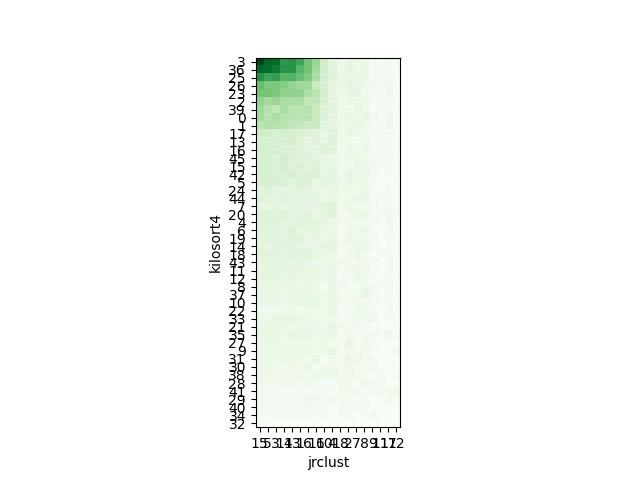

In [28]:
import spikeinterface.extractors as se
from pathlib import Path
import numpy as np
import scipy.io as sio
import spikeinterface.comparison as scmp
import spikeinterface.widgets as sw
import h5py
import matplotlib.pyplot as plt

%matplotlib widget

JRC_path = r"E:\Data\mPG_VV\3171_day12_260420_124757\pruned"
KS4_path = r"C:\Users\social\Desktop\temp_Brune\SpikeExplore\kilosort_output\victor\april_28_2026_b"

def read_jrclust_sorting_hdf5(jrclust_folder, sampling_frequency):
    jrclust_folder = Path(jrclust_folder)

    res_files = list(jrclust_folder.glob("*_res.mat"))
    if len(res_files) != 1:
        raise ValueError(f"Expected one *_res.mat file, found {len(res_files)}: {res_files}")

    res_file = res_files[0]

    with h5py.File(res_file, "r") as f:
        print("Available keys:", list(f.keys()))

        spike_times = np.array(f["spikeTimes"]).squeeze().astype("int64")
        # TODO unsure about this line below 
        spike_times = spike_times - 1
        spike_labels = np.array(f["spikeClusters"]).squeeze().astype("int64")

    # MATLAB/HDF5 sometimes gives shape (1, n) or (n, 1)
    spike_times = spike_times.ravel()
    spike_labels = spike_labels.ravel()

    # Keep only assigned clusters
    valid = spike_labels > 0

    spike_times = spike_times[valid]
    spike_labels = spike_labels[valid]

    # Sort by spike time
    order = np.argsort(spike_times)
    spike_times = spike_times[order]
    spike_labels = spike_labels[order]

    sorting = se.NumpySorting.from_samples_and_labels(
        samples_list=[spike_times],
        labels_list=[spike_labels],
        sampling_frequency=sampling_frequency,
    )

    return sorting


jr_sorting = read_jrclust_sorting_hdf5(JRC_path, sampling_frequency=20000.0)

ks4_sorting = se.read_kilosort(KS4_path, keep_good_only=False)
cmp = scmp.compare_two_sorters(
    sorting1=ks4_sorting,
    sorting2=jr_sorting,
    sorting1_name="kilosort4",
    sorting2_name="jrclust",
    delta_time=0.4,  # ms; SI default is commonly 0.4 ms
)

sw.plot_agreement_matrix(cmp, ordered=True, backend="matplotlib")


